In [4]:
import os
import pickle

pkl_path = "DiffVideo/Thin_Wide_SimpleMod_K_AA_02L_OriginalReward/A1MoveGroundMPC/0/Output_bestMPCThinWideSimpleMod_K_AA.pkl"  # replace
# pkl_path = "DiffVideo/Thin_Wide_Standard_02L_OriginalReward/A1MoveGroundMPC/0/Output_bestMPCThinWideMovingStandard.pkl"  # replace

with open(pkl_path, "rb") as f:
    data = pickle.load(f)

print(type(data))
print(data)

<class 'dict'>
{'reward': [449.1353510535658, 448.08641911638455, 639.511189268987, 448.11539826139386, 448.1178322679889], 'move_distance': [15.197862117587125, 15.194180195591038, 20.733630334371824, 15.194251415507685, 15.194281016456234], 'step': 735}


Loading: SimpleMod_K_AA
Loading: Standard
Loading: TopK

Available groups:
Thin
ThinRandomShape
ThinWideMoving
ThinHeightField
ThinWide
ThinGoal


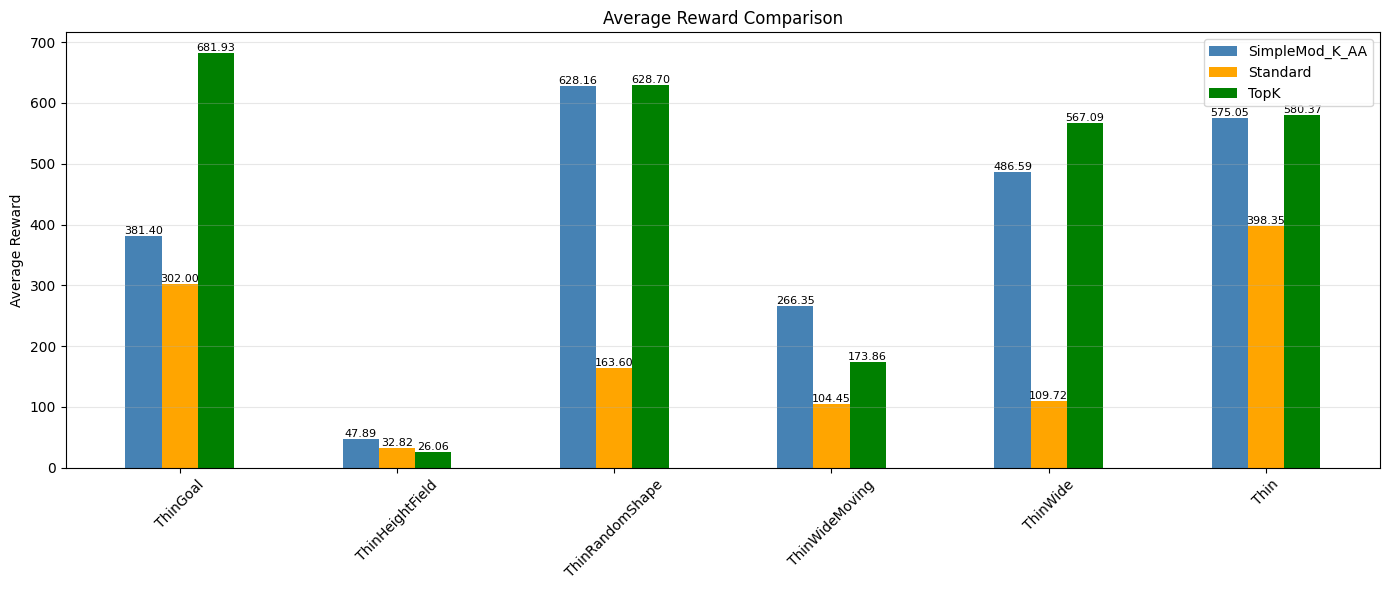

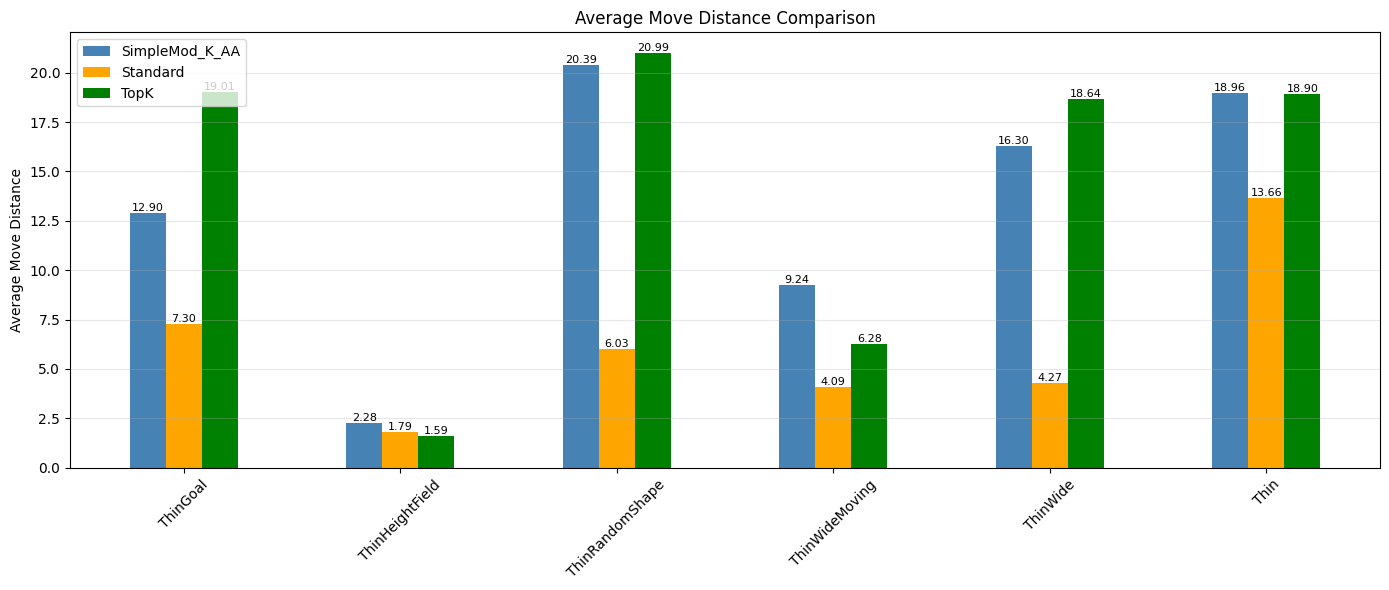

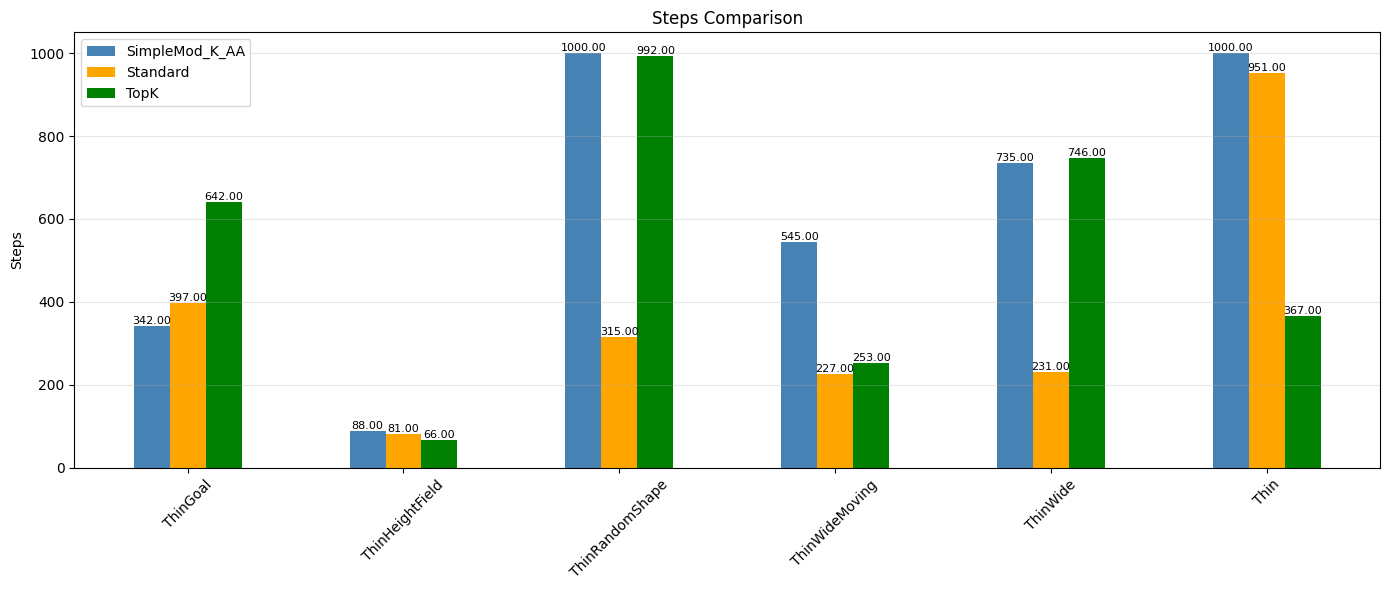

In [5]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt


# =====================================================
# Directories
# =====================================================

directories = {
    "SimpleMod_K_AA": 
        "DiffVideo/Thin_Wide_SimpleMod_K_AA_02L_OriginalReward/A1MoveGroundMPC/0/",

    "Standard": 
        "DiffVideo/Thin_Wide_Standard_02L_OriginalReward/A1MoveGroundMPC/0/",

    "TopK": 
        "../vision4leg_TopK/DiffVideo/Thin_Wide_SimpleMod_K_AA_02L_OriginalReward_TopK/A1MoveGroundMPC/0/"
}



# =====================================================
# File grouping
# =====================================================

group_keywords = {
    "ThinGoal": "ThinGoal",
    "ThinHeightField": "ThinHeightField",
    "ThinRandomShape": "ThinRandomShape",
    "ThinWideMoving": "ThinWideMoving",
    "ThinWide": "ThinWide",
    "Thin": "Thin"
}


def get_group(filename):

    for group, keyword in group_keywords.items():

        if keyword in filename:
            return group

    return None



# =====================================================
# Load PKL files
# =====================================================

def load_pkl_results(folder):

    results = {}

    for root, _, files in os.walk(folder):

        for file in files:

            if file.endswith(".pkl"):

                group = get_group(file)

                if group is None:
                    continue


                path = os.path.join(root, file)


                with open(path, "rb") as f:
                    data = pickle.load(f)


                results[path] = {
                    "group": group,
                    "data": data,
                    "file": file
                }


    return results



# =====================================================
# Read all experiments
# =====================================================

all_results = {}

for method, folder in directories.items():

    print("Loading:", method)

    all_results[method] = load_pkl_results(folder)



# =====================================================
# Arrange data by group
# =====================================================

grouped = {}


for method, files in all_results.items():

    for path, item in files.items():

        group = item["group"]
        data = item["data"]


        if group not in grouped:
            grouped[group] = {}


        if method not in grouped[group]:
            grouped[group][method] = []


        grouped[group][method].append(data)



print("\nAvailable groups:")
for g in grouped:
    print(g)



# =====================================================
# Plot settings
# =====================================================

terrain_groups = [
    "ThinGoal",
    "ThinHeightField",
    "ThinRandomShape",
    "ThinWideMoving",
    "ThinWide",
    "Thin"
]


methods = [
    "SimpleMod_K_AA",
    "Standard",
    "TopK"
]


colors = {
    "SimpleMod_K_AA": "steelblue",
    "Standard": "orange",
    "TopK": "green",
}



# =====================================================
# Plot function
# =====================================================

def plot_metric(metric_name, metric_key):

    plt.figure(figsize=(14,6))


    # x = np.arange(len(terrain_groups))
    x = np.array([
        0.0,   # ThinGoal
        1.5,   # ThinHeightField
        3.0,   # ThinRandomShape
        4.5,   # ThinWideMoving
        6.0,   # ThinWide
        7.5    # Thin
    ])

    width = 0.25


    for i, method in enumerate(methods):

        values = []


        for terrain in terrain_groups:


            if terrain in grouped and method in grouped[terrain]:

                temp = []


                for data in grouped[terrain][method]:


                    if metric_key == "step":

                        temp.append(data["step"])

                    else:

                        temp.append(
                            np.mean(data[metric_key])
                        )


                values.append(
                    np.mean(temp)
                )


            else:

                values.append(0)



        offset = (i-1)*width


        bars = plt.bar(
            x + offset,
            values,
            width,
            label=method,
            color=colors[method]
        )


        # numbers above bars
        for bar, value in zip(bars, values):

            plt.text(
                bar.get_x()+bar.get_width()/2,
                bar.get_height(),
                f"{value:.2f}",
                ha="center",
                va="bottom",
                fontsize=8
            )


    plt.xticks(
        x,
        terrain_groups,
        rotation=45
    )


    plt.ylabel(metric_name)

    plt.title(
        f"{metric_name} Comparison"
    )

    plt.legend()

    plt.grid(
        axis="y",
        alpha=0.3
    )


    plt.tight_layout()

    plt.show()



# =====================================================
# Generate plots
# =====================================================

plot_metric(
    "Average Reward",
    "reward"
)


plot_metric(
    "Average Move Distance",
    "move_distance"
)


plot_metric(
    "Steps",
    "step"
)

Loading: SimpleMod_K_AA
Loading: Standard
Loading: TopK
Loading: ActivePrecision
Loading: gMLP-02L
Loading: gMLP-03L

Available groups:
Thin
ThinRandomShape
ThinWideMoving
ThinHeightField
ThinWide
ThinGoal


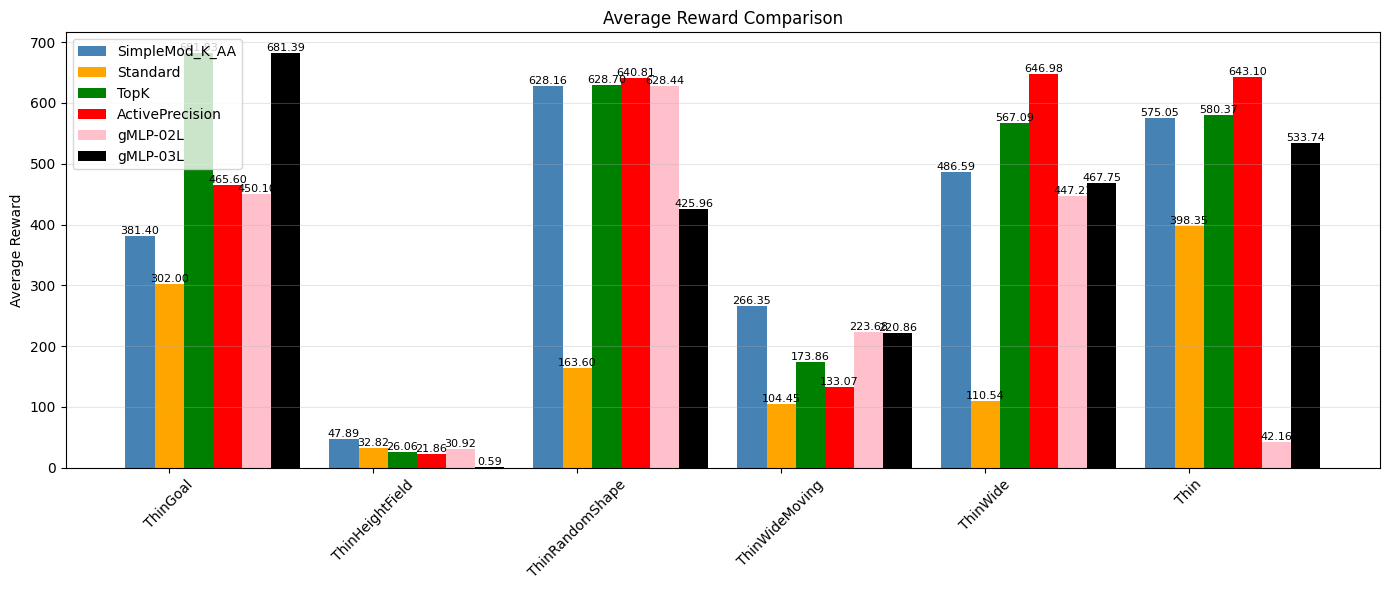

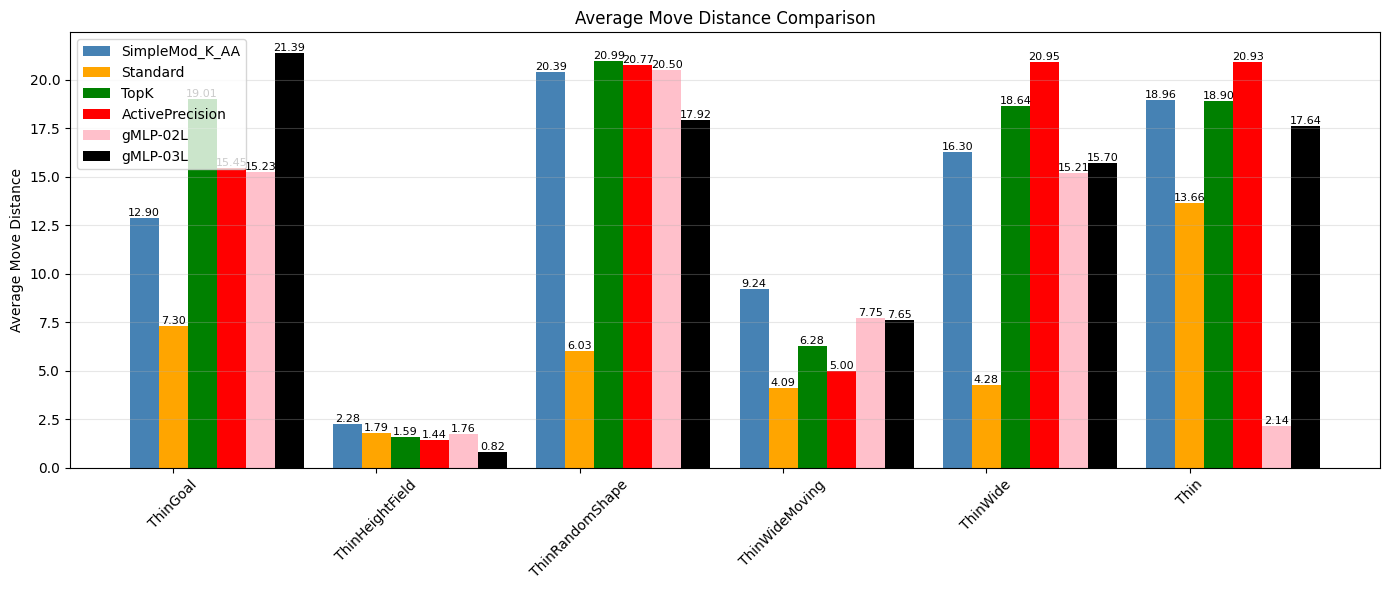

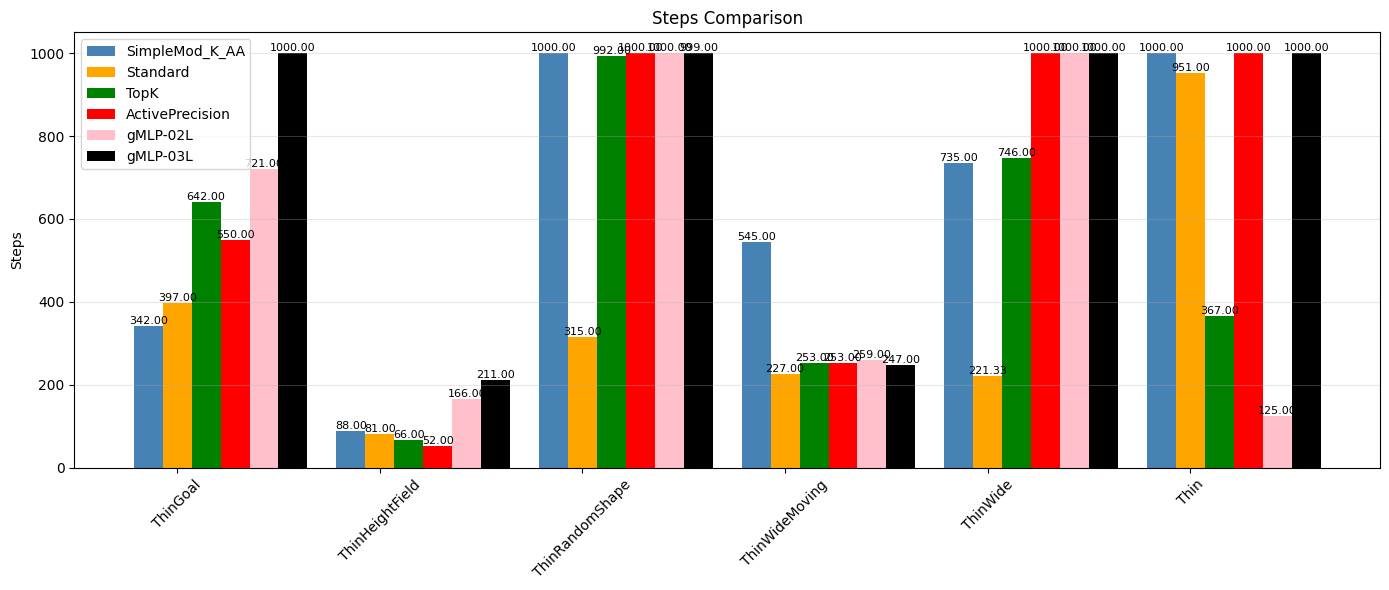

In [12]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt


# =====================================================
# Directories
# =====================================================

directories = {
    "SimpleMod_K_AA": 
        "DiffVideo/Thin_Wide_SimpleMod_K_AA_02L_OriginalReward/A1MoveGroundMPC/0/",

    "Standard": 
        "DiffVideo/Thin_Wide_Standard_02L_OriginalReward/A1MoveGroundMPC/0/",

    "TopK": 
        "../vision4leg_TopK/DiffVideo/Thin_Wide_SimpleMod_K_AA_02L_OriginalReward_TopK/A1MoveGroundMPC/0/",
    
     "ActivePrecision": 
        # "/home/tab7/Downloads/vision4leg_ActivePrecision/DiffVideo/Thin_Wide__SimpleMod_K_AA_02L_AP_Mean_On-All/A1MoveGroundMPC/0/"
        "/home/tab7/Downloads/vision4leg_ActivePrecision/DiffVideo/Thin_Wide_SimpleMod_K_AA_02L_ActivePrecision_Mean_On_All/A1MoveGroundMPC/0/",
     "gMLP-02L": 
        "/home/tab7/Downloads/vision4leg_original/vision4leg/DiffVideo/Thin_Wide_gMLP_02L/A1MoveGroundMPC/0/",
    "gMLP-03L": 
        "/home/tab7/Downloads/vision4leg_original/vision4leg/DiffVideo/Thin_Wide_gMLP_03L/A1MoveGroundMPC/0/",
    
}



# =====================================================
# File grouping
# =====================================================

group_keywords = {
    "ThinGoal": "ThinGoal",
    "ThinHeightField": "ThinHeightField",
    "ThinRandomShape": "ThinRandomShape",
    "ThinWideMoving": "ThinWideMoving",
    "ThinWide": "ThinWide",
    "Thin": "Thin"
}


def get_group(filename):

    for group, keyword in group_keywords.items():

        if keyword in filename:
            return group

    return None



# =====================================================
# Load PKL files
# =====================================================

def load_pkl_results(folder):

    results = {}

    for root, _, files in os.walk(folder):

        for file in files:

            if file.endswith(".pkl"):

                group = get_group(file)

                if group is None:
                    continue


                path = os.path.join(root, file)


                with open(path, "rb") as f:
                    data = pickle.load(f)


                results[path] = {
                    "group": group,
                    "data": data,
                    "file": file
                }


    return results



# =====================================================
# Read all experiments
# =====================================================

all_results = {}

for method, folder in directories.items():

    print("Loading:", method)

    all_results[method] = load_pkl_results(folder)



# =====================================================
# Arrange data by group
# =====================================================

grouped = {}


for method, files in all_results.items():

    for path, item in files.items():

        group = item["group"]
        data = item["data"]


        if group not in grouped:
            grouped[group] = {}


        if method not in grouped[group]:
            grouped[group][method] = []


        grouped[group][method].append(data)



print("\nAvailable groups:")
for g in grouped:
    print(g)



# =====================================================
# Plot settings
# =====================================================

terrain_groups = [
    "ThinGoal",
    "ThinHeightField",
    "ThinRandomShape",
    "ThinWideMoving",
    "ThinWide",
    "Thin"
]


methods = [
    "SimpleMod_K_AA",
    "Standard",
    "TopK",
    "ActivePrecision",
    "gMLP-02L",
    "gMLP-03L"
]


colors = {
    "SimpleMod_K_AA": "steelblue",
    "Standard": "orange",
    "TopK": "green",
    "ActivePrecision": "red",
    "gMLP-02L": "pink",
    "gMLP-03L": "black"
}



# =====================================================
# Plot function
# =====================================================

def plot_metric(metric_name, metric_key):

    plt.figure(figsize=(14,6))


    # x = np.arange(len(terrain_groups))
    x = np.arange(len(terrain_groups)) * 1.75   # control spacing between groups
    width = 0.25                               # control width of each bar


    for i, method in enumerate(methods):

        values = []


        for terrain in terrain_groups:


            if terrain in grouped and method in grouped[terrain]:

                temp = []


                for data in grouped[terrain][method]:


                    if metric_key == "step":

                        temp.append(data["step"])

                    else:

                        temp.append(
                            np.mean(data[metric_key])
                        )


                values.append(
                    np.mean(temp)
                )


            else:

                values.append(0)



        offset = (i-1)*width


        bars = plt.bar(
            x + offset,
            values,
            width,
            label=method,
            color=colors[method]
        )


        # numbers above bars
        for bar, value in zip(bars, values):

            plt.text(
                bar.get_x()+bar.get_width()/2,
                bar.get_height(),
                f"{value:.2f}",
                ha="center",
                va="bottom",
                fontsize=8
            )


    plt.xticks(
        x,
        terrain_groups,
        rotation=45
    )


    plt.ylabel(metric_name)

    plt.title(
        f"{metric_name} Comparison"
    )

    plt.legend()

    plt.grid(
        axis="y",
        alpha=0.3
    )


    plt.tight_layout()

    plt.show()



# =====================================================
# Generate plots
# =====================================================

plot_metric(
    "Average Reward",
    "reward"
)


plot_metric(
    "Average Move Distance",
    "move_distance"
)


plot_metric(
    "Steps",
    "step"
)

Loading: SimpleMod_K_AA
Loading: SimpleMod_K_ADA
Loading: Standard
Loading: TopK
Loading: ActivePrecision
Loading: gMLP-02L
Loading: gMLP-03L

Available groups:
Thin
ThinRandomShape
ThinWideMoving
ThinHeightField
ThinWide
ThinGoal


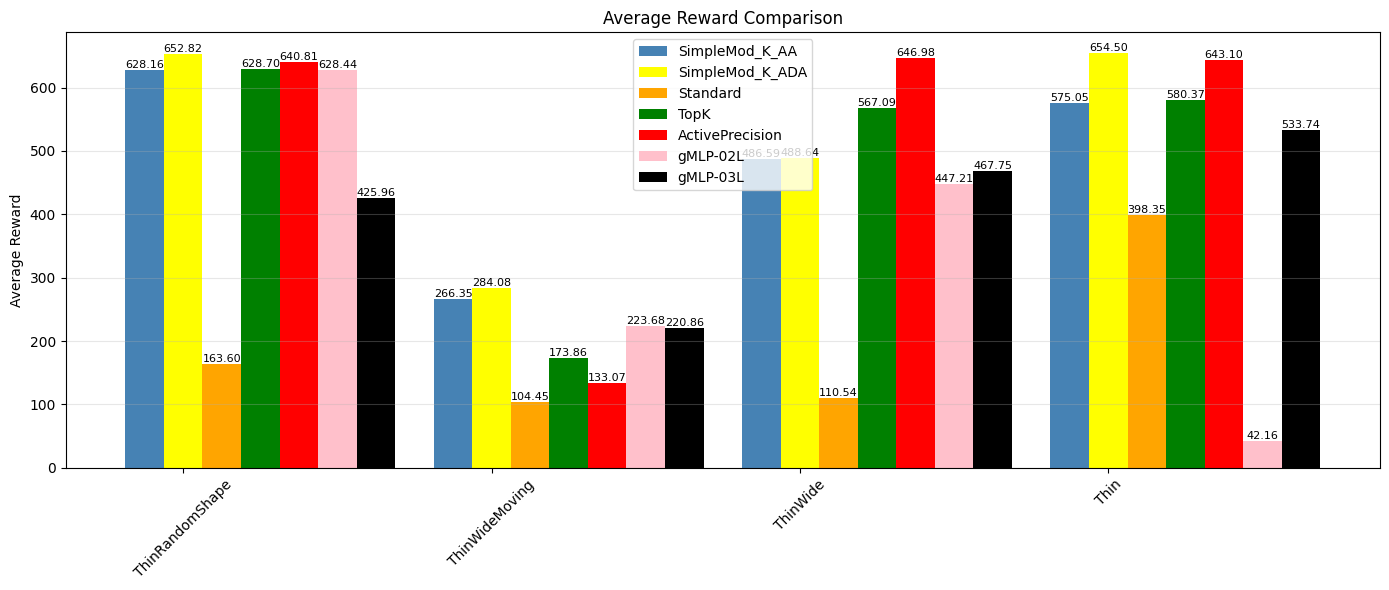

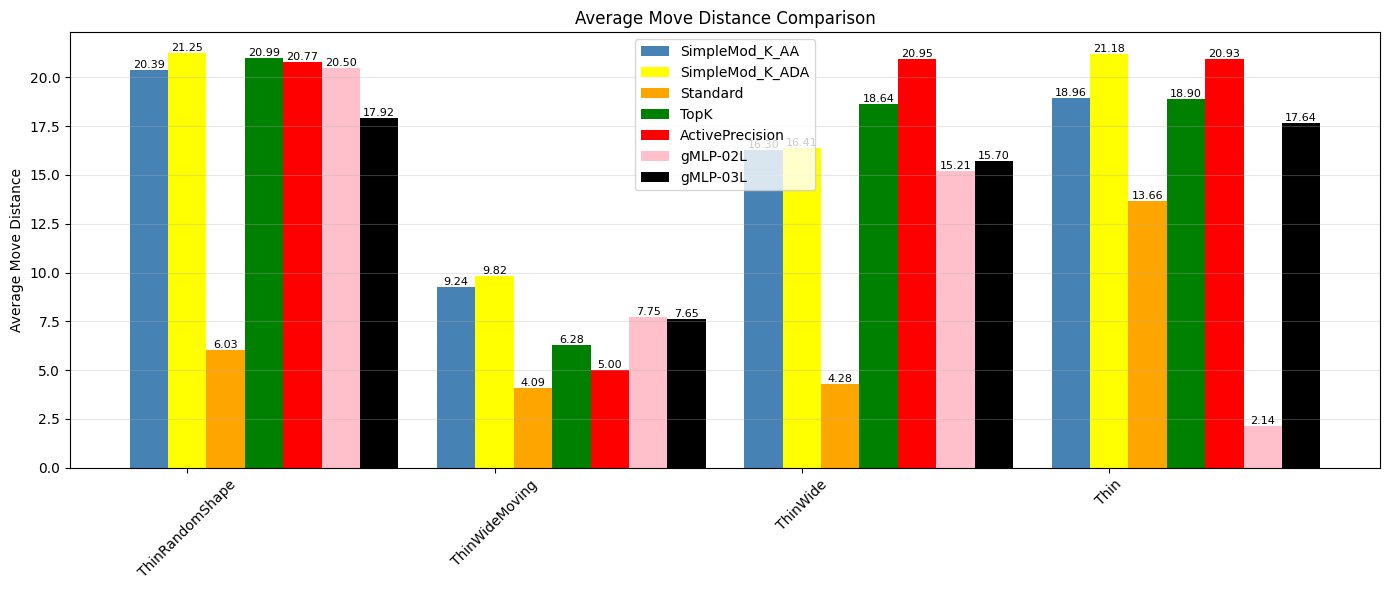

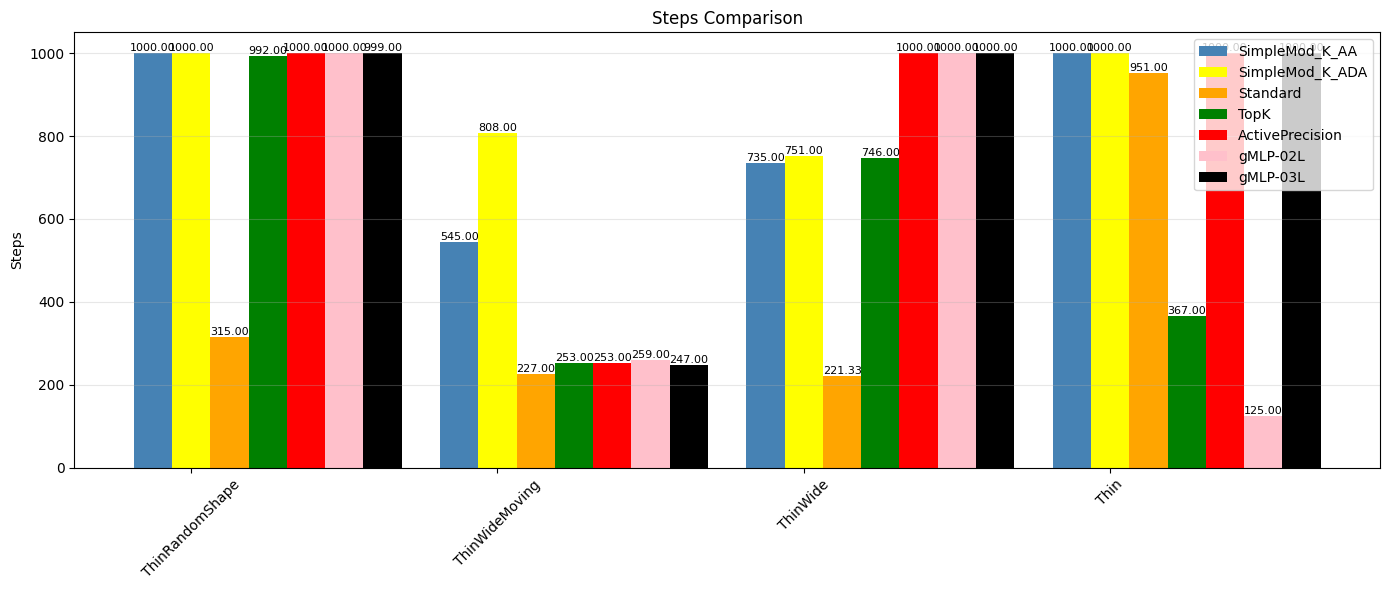

In [7]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt


# =====================================================
# Directories
# =====================================================

directories = {
    "SimpleMod_K_AA": 
        "DiffVideo/Thin_Wide_SimpleMod_K_AA_02L_OriginalReward/A1MoveGroundMPC/0/",
    
    "SimpleMod_K_ADA": 
        "DiffVideo/Thin_Wide_SimpleMod_K_ADA_02L/A1MoveGroundMPC/0/",

    "Standard": 
        "DiffVideo/Thin_Wide_Standard_02L_OriginalReward/A1MoveGroundMPC/0/",

    "TopK": 
        "../vision4leg_TopK/DiffVideo/Thin_Wide_SimpleMod_K_AA_02L_OriginalReward_TopK/A1MoveGroundMPC/0/",
    
     "ActivePrecision": 
        # "/home/tab7/Downloads/vision4leg_ActivePrecision/DiffVideo/Thin_Wide__SimpleMod_K_AA_02L_AP_Mean_On-All/A1MoveGroundMPC/0/"
        "/home/tab7/Downloads/vision4leg_ActivePrecision/DiffVideo/Thin_Wide_SimpleMod_K_AA_02L_ActivePrecision_Mean_On_All/A1MoveGroundMPC/0/",
     "gMLP-02L": 
        "/home/tab7/Downloads/vision4leg_original/vision4leg/DiffVideo/Thin_Wide_gMLP_02L/A1MoveGroundMPC/0/",
    "gMLP-03L": 
        "/home/tab7/Downloads/vision4leg_original/vision4leg/DiffVideo/Thin_Wide_gMLP_03L/A1MoveGroundMPC/0/",
    
}



# =====================================================
# File grouping
# =====================================================

group_keywords = {
    "ThinGoal": "ThinGoal",
    "ThinHeightField": "ThinHeightField",
    "ThinRandomShape": "ThinRandomShape",
    "ThinWideMoving": "ThinWideMoving",
    "ThinWide": "ThinWide",
    "Thin": "Thin"
}


def get_group(filename):

    for group, keyword in group_keywords.items():

        if keyword in filename:
            return group

    return None



# =====================================================
# Load PKL files
# =====================================================

def load_pkl_results(folder):

    results = {}

    for root, _, files in os.walk(folder):

        for file in files:

            if file.endswith(".pkl"):

                group = get_group(file)

                if group is None:
                    continue


                path = os.path.join(root, file)


                with open(path, "rb") as f:
                    data = pickle.load(f)


                results[path] = {
                    "group": group,
                    "data": data,
                    "file": file
                }


    return results



# =====================================================
# Read all experiments
# =====================================================

all_results = {}

for method, folder in directories.items():

    print("Loading:", method)

    all_results[method] = load_pkl_results(folder)



# =====================================================
# Arrange data by group
# =====================================================

grouped = {}


for method, files in all_results.items():

    for path, item in files.items():

        group = item["group"]
        data = item["data"]


        if group not in grouped:
            grouped[group] = {}


        if method not in grouped[group]:
            grouped[group][method] = []


        grouped[group][method].append(data)



print("\nAvailable groups:")
for g in grouped:
    print(g)



# =====================================================
# Plot settings
# =====================================================

terrain_groups = [
    # "ThinGoal",
    # "ThinHeightField",
    "ThinRandomShape",
    "ThinWideMoving",
    "ThinWide",
    "Thin"
]


methods = [
    "SimpleMod_K_AA",
    "SimpleMod_K_ADA",
    "Standard",
    "TopK",
    "ActivePrecision",
    "gMLP-02L",
    "gMLP-03L"
]


colors = {
    "SimpleMod_K_AA": "steelblue",
    "SimpleMod_K_ADA": "yellow",
    "Standard": "orange",
    "TopK": "green",
    "ActivePrecision": "red",
    "gMLP-02L": "pink",
    "gMLP-03L": "black"
}



# =====================================================
# Plot function
# =====================================================

def plot_metric(metric_name, metric_key):

    plt.figure(figsize=(14,6))


    # x = np.arange(len(terrain_groups))
    x = np.arange(len(terrain_groups)) * 2   # control spacing between groups
    width = 0.25                               # control width of each bar


    for i, method in enumerate(methods):

        values = []


        for terrain in terrain_groups:


            if terrain in grouped and method in grouped[terrain]:

                temp = []


                for data in grouped[terrain][method]:


                    if metric_key == "step":

                        temp.append(data["step"])

                    else:

                        temp.append(
                            np.mean(data[metric_key])
                        )


                values.append(
                    np.mean(temp)
                )


            else:

                values.append(0)



        offset = (i-1)*width


        bars = plt.bar(
            x + offset,
            values,
            width,
            label=method,
            color=colors[method]
        )


        # numbers above bars
        for bar, value in zip(bars, values):

            plt.text(
                bar.get_x()+bar.get_width()/2,
                bar.get_height(),
                f"{value:.2f}",
                ha="center",
                va="bottom",
                fontsize=8
            )


    plt.xticks(
        x,
        terrain_groups,
        rotation=45
    )


    plt.ylabel(metric_name)

    plt.title(
        f"{metric_name} Comparison"
    )

    plt.legend()

    plt.grid(
        axis="y",
        alpha=0.3
    )


    plt.tight_layout()

    plt.show()



# =====================================================
# Generate plots
# =====================================================

plot_metric(
    "Average Reward",
    "reward"
)


plot_metric(
    "Average Move Distance",
    "move_distance"
)


plot_metric(
    "Steps",
    "step"
)